In [2]:
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

sample_path = Path(
    "../data/processed/AD_1_LS/AD_1_LS"
)

adata = sc.read_10x_h5(
    sample_path / "filtered_feature_bc_matrix.h5"
)

adata.var_names_make_unique()

print(adata)
print("Number of spots:", adata.n_obs)
print("Number of genes:", adata.n_vars)

AnnData object with n_obs × n_vars = 188 × 21587
    var: 'gene_ids', 'feature_types', 'genome'
Number of spots: 188
Number of genes: 21587


c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


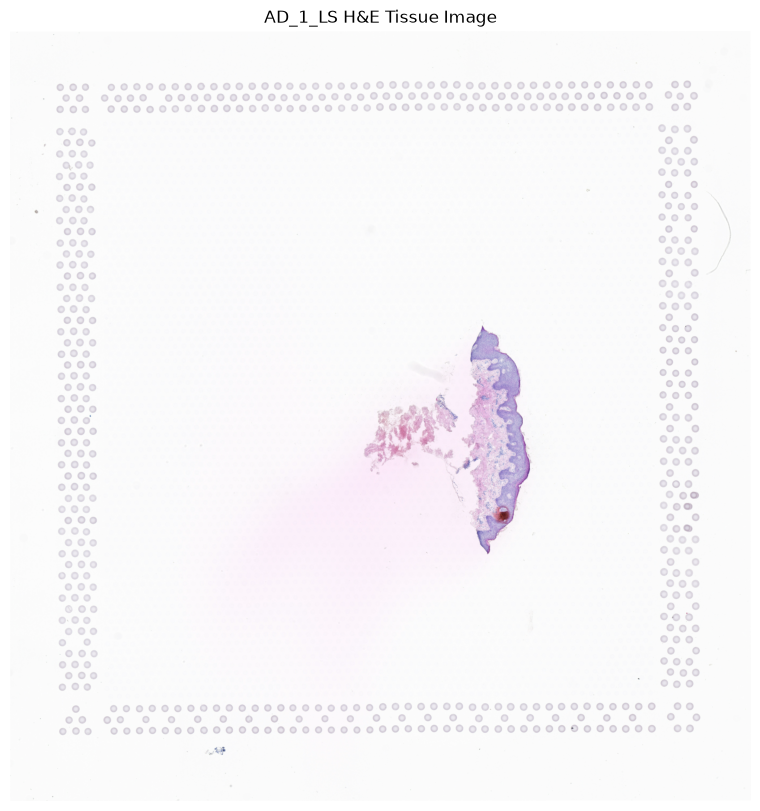

In [3]:
from PIL import Image

image_path = sample_path / "spatial/tissue_hires_image.png"

img = Image.open(image_path)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.title("AD_1_LS H&E Tissue Image")
plt.show()

In [4]:
# Basic dataset information

print("Dataset shape:", adata.shape)

print("\nSample information:")
print(adata.obs.head())

print("\nGene information:")
print(adata.var.head())

print("\nTotal counts per spot:")
print(adata.X.sum(axis=1)[:10])

Dataset shape: (188, 21587)

Sample information:
Empty DataFrame
Columns: []
Index: [AAAGTGTGATTTATCT-1, AAAGTTGACTCCCGTA-1, AACACACGCTCGCCGC-1, AACCCTACTGTCAATA-1, AACCGCTAAGGGATGC-1]

Gene information:
               gene_ids    feature_types  \
OR4F5   ENSG00000186092  Gene Expression   
OR4F29  ENSG00000284733  Gene Expression   
OR4F16  ENSG00000284662  Gene Expression   
SAMD11  ENSG00000187634  Gene Expression   
NOC2L   ENSG00000188976  Gene Expression   

                                                   genome  
OR4F5   genes_10XGEX_SC_Mt_rRNA-Mt_tRNA-protein_coding...  
OR4F29  genes_10XGEX_SC_Mt_rRNA-Mt_tRNA-protein_coding...  
OR4F16  genes_10XGEX_SC_Mt_rRNA-Mt_tRNA-protein_coding...  
SAMD11  genes_10XGEX_SC_Mt_rRNA-Mt_tRNA-protein_coding...  
NOC2L   genes_10XGEX_SC_Mt_rRNA-Mt_tRNA-protein_coding...  

Total counts per spot:
[[42594.]
 [54693.]
 [42126.]
 [39266.]
 [19942.]
 [32418.]
 [24183.]
 [18372.]
 [ 3406.]
 [ 3456.]]


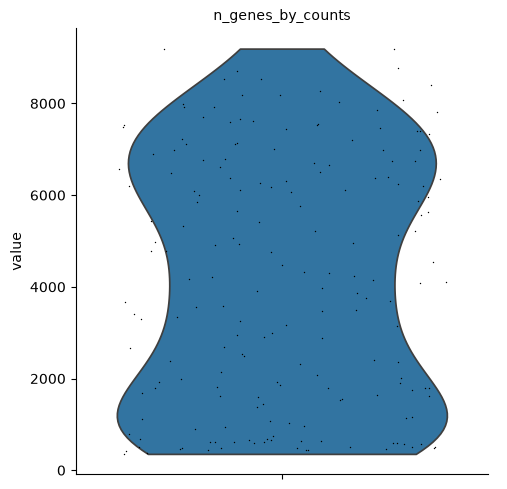

In [5]:
# Calculate quality metrics
sc.pp.calculate_qc_metrics(
    adata,
    inplace=True
)

# Plot number of detected genes per spot
sc.pl.violin(
    adata,
    ["n_genes_by_counts"],
    jitter=0.4,
    multi_panel=True
)